# xTB vs DFT Geometry and Steric Descriptor Comparison

This notebook addresses the reviewer request to compare xTB-optimized transition-state geometries with DFT-optimized geometries. It calculates all-atom, heavy-atom, and steric-substructure RMSD after ASE alignment, then recalculates the steric descriptors used in the TS descriptor pipeline on both geometries.

Inputs:
- xTB structures: `../xtb_dft_comparation/xtb/<structure_id>/xtb/tsopted.xyz`
- DFT structures: final `Standard orientation` block in `../xtb_dft_comparation/dft/<structure_id>.log`
- Steric descriptor names/order: `../xtb_dft_comparation/xtb/<structure_id>/xtb/desc.npz`

Outputs are written to `../xtb_dft_comparation/results/`.


In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import minimize_rotation_and_translation

# Locate project root robustly whether this notebook is run from scripts/ or project root.
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start] + list(start.parents):
        if (path / 'xtb_dft_comparation').exists() and (path / 'rxnpredict').exists():
            return path
    raise RuntimeError('Could not locate FerroEnantioML project root.')

PROJECT_ROOT = find_project_root()
COMPARISON_DIR = PROJECT_ROOT / 'xtb_dft_comparation'
DFT_DIR = COMPARISON_DIR / 'dft'
XTB_DIR = COMPARISON_DIR / 'xtb'
RESULT_DIR = COMPARISON_DIR / 'results'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from rxnpredict.descriptors.calc import StericDescriptor

print('Project root:', PROJECT_ROOT)
print('DFT logs:', len(list(DFT_DIR.glob('*.log'))))
print('xTB folders:', len([p for p in XTB_DIR.iterdir() if p.is_dir()]))


Project root: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML
DFT logs: 16
xTB folders: 16


In [2]:
ATOM_NUM_TO_SYMBOL = {
    1: 'H',
    6: 'C',
    7: 'N',
    8: 'O',
    15: 'P',
    16: 'S',
    26: 'Fe',
    46: 'Pd',
}


def read_xyz(path):
    path = Path(path)
    lines = path.read_text().splitlines()
    natoms = int(lines[0].strip())
    symbols = []
    coords = []
    for line in lines[2:2 + natoms]:
        parts = line.split()
        symbols.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    return symbols, np.asarray(coords, dtype=float)


def write_xyz(path, symbols, coords, comment=''):
    path = Path(path)
    with path.open('w') as fw:
        fw.write(f'{len(symbols)}\n{comment}\n')
        for symbol, (x, y, z) in zip(symbols, coords):
            fw.write(f'{symbol:2s} {x: .8f} {y: .8f} {z: .8f}\n')


def read_final_gaussian_orientation(log_path):
    lines = Path(log_path).read_text(errors='ignore').splitlines()
    starts = [i for i, line in enumerate(lines) if 'Standard orientation:' in line]
    if not starts:
        starts = [i for i, line in enumerate(lines) if 'Input orientation:' in line]
    if not starts:
        raise ValueError(f'No Gaussian orientation block found in {log_path}')

    start = starts[-1]
    rows = []
    idx = start + 5
    while idx < len(lines) and '-----' not in lines[idx]:
        parts = lines[idx].split()
        if len(parts) >= 6:
            rows.append(parts)
        idx += 1

    symbols = [ATOM_NUM_TO_SYMBOL.get(int(row[1]), str(row[1])) for row in rows]
    coords = np.asarray([[float(row[3]), float(row[4]), float(row[5])] for row in rows], dtype=float)
    return symbols, coords


def ase_aligned_positions(symbols, mobile_coords, reference_coords, atom_indices=None):
    if atom_indices is None:
        atom_indices = np.arange(len(symbols), dtype=int)
    atom_indices = np.asarray(atom_indices, dtype=int)
    subset_symbols = [symbols[idx] for idx in atom_indices]
    target = Atoms(subset_symbols, positions=np.asarray(reference_coords, dtype=float)[atom_indices])
    atoms = Atoms(subset_symbols, positions=np.asarray(mobile_coords, dtype=float)[atom_indices])
    minimize_rotation_and_translation(target, atoms)
    return atoms.get_positions()


def ase_rmsd(symbols, mobile_coords, reference_coords, atom_indices=None):
    if atom_indices is None:
        atom_indices = np.arange(len(symbols), dtype=int)
    atom_indices = np.asarray(atom_indices, dtype=int)
    aligned = ase_aligned_positions(symbols, mobile_coords, reference_coords, atom_indices=atom_indices)
    reference_subset = np.asarray(reference_coords, dtype=float)[atom_indices]
    delta = aligned - reference_subset
    return float(np.sqrt(np.mean(np.sum(delta * delta, axis=1))))


def ase_align_full_structure(symbols, mobile_coords, reference_coords):
    target = Atoms(symbols, positions=np.asarray(reference_coords, dtype=float))
    atoms = Atoms(symbols, positions=np.asarray(mobile_coords, dtype=float))
    minimize_rotation_and_translation(target, atoms)
    return atoms.get_positions()


In [3]:
def steric_names_from_desc_npz(desc_npz_path):
    desc = np.load(desc_npz_path, allow_pickle=True)
    names = [str(name) for name in desc['desc_names']]
    return [name for name in names if name.startswith(('bv_', 'b1_', 'b5_', 'l_'))]


def steric_atom_indices_from_names(steric_names):
    atom_indices = set()
    for name in steric_names:
        parts = name.split('_')
        desc_type = parts[0]
        if desc_type == 'bv':
            atom_indices.add(int(parts[1]) - 1)
        elif desc_type in {'b1', 'b5', 'l'}:
            atom_indices.add(int(parts[1]) - 1)
            atom_indices.add(int(parts[2]) - 1)
        else:
            raise ValueError(f'Unknown steric descriptor name: {name}')
    return np.asarray(sorted(atom_indices), dtype=int)


def calc_steric_by_names(xyz_file, steric_names):
    # Equivalent to get_steric_loc_desc, but driven by the descriptor names saved by
    # the original TS descriptor pipeline. This avoids re-inferring attachment atoms.
    steric = StericDescriptor(str(xyz_file))
    values = []
    sterimol_cache = {}

    for name in steric_names:
        parts = name.split('_')
        desc_type = parts[0]
        if desc_type == 'bv':
            atom_idx = int(parts[1]) - 1
            values.extend(steric.BV(atom_idx))
        elif desc_type in {'b1', 'b5', 'l'}:
            pair = (int(parts[1]) - 1, int(parts[2]) - 1)
            if pair not in sterimol_cache:
                sterimol_cache[pair] = steric.Sterimol(dummy_index=pair[0], attached_index=pair[1])
            b1, b5, length = sterimol_cache[pair]
            values.append({'b1': b1, 'b5': b5, 'l': length}[desc_type])
        else:
            raise ValueError(f'Unknown steric descriptor name: {name}')

    return np.asarray(values, dtype=float)


def linear_relationship(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.isclose(np.std(x), 0.0) or np.isclose(np.std(y), 0.0):
        return np.nan, np.nan, np.nan, np.nan
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    pearson_r = float(np.corrcoef(x, y)[0, 1])
    ss_res = float(np.sum((y - y_pred) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = np.nan if np.isclose(ss_tot, 0.0) else 1.0 - ss_res / ss_tot
    return float(slope), float(intercept), pearson_r, float(r2)


def zscore(series):
    std = series.std(ddof=0)
    if std == 0:
        return series * 0.0
    return (series - series.mean()) / std


In [4]:
summary_records = []
diff_records = []

for dft_log in sorted(DFT_DIR.glob('*.log')):
    structure_id = dft_log.stem
    xtb_xyz = XTB_DIR / structure_id / 'xtb' / 'tsopted.xyz'
    xtb_topology = XTB_DIR / structure_id / 'xtb' / 'xtbtopo.mol'
    desc_npz = XTB_DIR / structure_id / 'xtb' / 'desc.npz'

    missing = [str(path) for path in [xtb_xyz, xtb_topology, desc_npz] if not path.exists()]
    if missing:
        raise FileNotFoundError(f'{structure_id}: missing input files: {missing}')

    xtb_symbols, xtb_coords = read_xyz(xtb_xyz)
    dft_symbols, dft_coords = read_final_gaussian_orientation(dft_log)
    if xtb_symbols != dft_symbols:
        raise ValueError(f'{structure_id}: atom symbols/order differ between xTB and DFT geometries.')

    heavy_atom_indices = np.asarray([idx for idx, symbol in enumerate(xtb_symbols) if symbol != 'H'], dtype=int)
    steric_names = steric_names_from_desc_npz(desc_npz)
    steric_atom_indices = steric_atom_indices_from_names(steric_names)
    xtb_steric = calc_steric_by_names(xtb_xyz, steric_names)

    saved_desc = np.load(desc_npz, allow_pickle=True)
    saved_names = [str(name) for name in saved_desc['desc_names']]
    saved_values = np.asarray(saved_desc['desc_values'], dtype=float)
    steric_mask = np.asarray([name.startswith(('bv_', 'b1_', 'b5_', 'l_')) for name in saved_names])
    saved_steric = saved_values[steric_mask]
    if not np.allclose(xtb_steric, saved_steric, rtol=1e-10, atol=1e-10):
        raise ValueError(f'{structure_id}: re-calculated xTB steric descriptors do not match desc.npz.')
    xtb_steric_recalculation_max_abs_error = float(np.max(np.abs(xtb_steric - saved_steric)))

    with tempfile.TemporaryDirectory() as tmpdir:
        dft_xyz = Path(tmpdir) / f'{structure_id}_dft.xyz'
        write_xyz(dft_xyz, dft_symbols, dft_coords, comment='DFT final geometry from Gaussian log')
        dft_steric = calc_steric_by_names(dft_xyz, steric_names)

    steric_delta = dft_steric - xtb_steric
    slope, intercept, pearson_r, linear_r2 = linear_relationship(xtb_steric, dft_steric)

    summary_records.append({
        'structure_id': structure_id,
        'series': structure_id.split('_')[0],
        'all_atom_rmsd_A': ase_rmsd(xtb_symbols, xtb_coords, dft_coords),
        'heavy_atom_rmsd_A': ase_rmsd(xtb_symbols, xtb_coords, dft_coords, heavy_atom_indices),
        'steric_atom_rmsd_A': ase_rmsd(xtb_symbols, xtb_coords, dft_coords, steric_atom_indices),
        'steric_mae': float(np.mean(np.abs(steric_delta))),
        'steric_rmse': float(np.sqrt(np.mean(steric_delta ** 2))),
        'steric_max_abs': float(np.max(np.abs(steric_delta))),
        'steric_linear_slope': slope,
        'steric_linear_intercept': intercept,
        'steric_linear_pearson_r': pearson_r,
        'steric_linear_abs_pearson_r': abs(pearson_r),
        'steric_linear_r2': linear_r2,
        'n_atoms': len(xtb_symbols),
        'n_heavy_atoms': len(heavy_atom_indices),
        'n_steric_atoms': len(steric_atom_indices),
        'n_steric_desc': len(steric_names),
        'steric_atom_indices_0based': ';'.join(map(str, steric_atom_indices.tolist())),
        'steric_atom_indices_1based': ';'.join(map(str, (steric_atom_indices + 1).tolist())),
        'xtb_steric_recalculation_max_abs_error': xtb_steric_recalculation_max_abs_error,
    })

    name_counts = {}
    for name, xtb_value, dft_value, delta in zip(steric_names, xtb_steric, dft_steric, steric_delta):
        name_counts[name] = name_counts.get(name, 0) + 1
        descriptor_instance = name if name_counts[name] == 1 else f'{name}__{name_counts[name]}'
        diff_records.append({
            'structure_id': structure_id,
            'series': structure_id.split('_')[0],
            'descriptor': name,
            'descriptor_instance': descriptor_instance,
            'xtb_value': float(xtb_value),
            'dft_value': float(dft_value),
            'delta_dft_minus_xtb': float(delta),
            'abs_delta': float(abs(delta)),
        })

summary_df = pd.DataFrame(summary_records).sort_values('all_atom_rmsd_A').reset_index(drop=True)
diff_df = pd.DataFrame(diff_records)
summary_df['rmsd_rank'] = np.arange(1, len(summary_df) + 1)
summary_df['combined_score'] = 0.5 * zscore(summary_df['all_atom_rmsd_A']) + 0.5 * zscore(summary_df['steric_rmse'])
summary_df = summary_df.sort_values('combined_score').reset_index(drop=True)
summary_df['combined_rank'] = np.arange(1, len(summary_df) + 1)
summary_df = summary_df.sort_values('steric_linear_abs_pearson_r', ascending=False).reset_index(drop=True)
summary_df['steric_linear_rank'] = np.arange(1, len(summary_df) + 1)
summary_df = summary_df.sort_values('all_atom_rmsd_A').reset_index(drop=True)

summary_csv = RESULT_DIR / 'xtb_dft_structure_steric_summary.csv'
diff_csv = RESULT_DIR / 'xtb_dft_steric_descriptor_diff.csv'
summary_df.to_csv(summary_csv, index=False)
diff_df.to_csv(diff_csv, index=False)

print('Saved:', summary_csv)
print('Saved:', diff_csv)
display(summary_df)


Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/xtb_dft_comparation/results/xtb_dft_structure_steric_summary.csv
Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/xtb_dft_comparation/results/xtb_dft_steric_descriptor_diff.csv


,structure_id,series,all_atom_rmsd_A,heavy_atom_rmsd_A,steric_atom_rmsd_A,steric_mae,steric_rmse,steric_max_abs,steric_linear_slope,steric_linear_intercept,...,n_heavy_atoms,n_steric_atoms,n_steric_desc,steric_atom_indices_0based,steric_atom_indices_1based,xtb_steric_recalculation_max_abs_error,rmsd_rank,combined_score,combined_rank,steric_linear_rank
0,rp_2_2,rp,1.089856,0.841913,0.178688,0.148007,0.300918,0.879273,1.091252,-0.140092,...,40,5,9,2;17;19;31;32,3;18;20;32;33,0.000000e+00,1,-1.219293,1,4
1,sp_7_1,sp,1.253781,1.164941,0.293198,0.223027,0.547336,1.631889,1.190108,-0.282874,...,32,5,9,2;17;19;32;41,3;18;20;33;42,0.000000e+00,2,-0.699520,4,8
2,sp_8_1,sp,1.372166,1.251626,0.522271,0.165158,0.354760,1.044519,1.118156,-0.195361,...,31,5,9,2;17;19;32;41,3;18;20;33;42,0.000000e+00,3,-0.985044,2,2
3,sp_5_1,sp,1.398095,1.290130,0.531962,0.239770,0.537751,1.594807,1.175624,-0.282942,...,27,5,9,2;17;19;32;41,3;18;20;33;42,0.000000e+00,4,-0.645962,5,9
4,sp_1_1,sp,1.407205,1.240430,0.421524,0.207481,0.454151,1.341459,1.154969,-0.239659,...,32,5,9,2;17;19;32;41,3;18;20;33;42,4.440892e-16,5,-0.790613,3,5
5,sp_3_1,sp,1.465915,1.286957,1.148035,0.234683,0.567310,1.688791,1.179458,-0.258443,...,32,5,9,2;17;19;32;44,3;18;20;33;45,8.881784e-16,6,-0.560034,7,7
6,sp_0_1,sp,2.075499,1.933961,0.601604,0.257143,0.394327,0.831690,1.103394,-0.177902,...,35,5,9,2;17;19;32;41,3;18;20;33;42,0.000000e+00,7,-0.570126,6,10
7,sp_6_1,sp,2.590505,2.215813,0.982060,0.194372,0.390982,1.141590,1.092535,-0.131975,...,46,5,9,2;17;19;32;64,3;18;20;33;65,0.000000e+00,8,-0.323950,8,1
8,rp_5_1,rp,2.690536,2.264590,0.277142,0.419502,0.786205,2.110974,1.149860,-0.238573,...,27,5,9,2;17;19;32;41,3;18;20;33;42,8.881784e-16,9,0.429954,12,14
9,rp_7_1,rp,2.810770,2.344253,0.384355,0.252642,0.542512,1.593887,1.177322,-0.207517,...,32,5,9,2;17;19;32;41,3;18;20;33;42,1.776357e-15,10,0.054163,9,6


In [5]:
steric_names

['bv_3',
 'bv_18',
 'bv_20',
 'bv_33',
 'bv_20',
 'bv_42',
 'b1_20_42',
 'b5_20_42',
 'l_20_42']

In [6]:
top8_by_rmsd = summary_df.nsmallest(8, 'all_atom_rmsd_A')
top8_by_steric_atom_rmsd = summary_df.nsmallest(8, 'steric_atom_rmsd_A')
top8_by_combined = summary_df.nsmallest(8, 'combined_score')
top8_by_linear = summary_df.nlargest(8, 'steric_linear_abs_pearson_r')

print('Eight structures with the smallest all-atom RMSD:')
display(top8_by_rmsd[['structure_id', 'all_atom_rmsd_A', 'heavy_atom_rmsd_A', 'steric_atom_rmsd_A', 'steric_rmse', 'steric_mae']])

print('Eight structures with the smallest steric-substructure RMSD:')
display(top8_by_steric_atom_rmsd[['structure_id', 'steric_atom_rmsd_A', 'steric_atom_indices_1based', 'all_atom_rmsd_A', 'steric_rmse']])

print('Eight structures with the smallest combined normalized geometry/steric difference score:')
display(top8_by_combined[['structure_id', 'combined_score', 'all_atom_rmsd_A', 'steric_atom_rmsd_A', 'steric_rmse', 'steric_mae']])

print('Eight structures with the strongest linear relationship between xTB and DFT steric descriptors:')
display(top8_by_linear[['structure_id', 'steric_linear_pearson_r', 'steric_linear_r2', 'steric_linear_slope', 'steric_linear_intercept', 'steric_rmse']])


Eight structures with the smallest all-atom RMSD:


,structure_id,all_atom_rmsd_A,heavy_atom_rmsd_A,steric_atom_rmsd_A,steric_rmse,steric_mae
0,rp_2_2,1.089856,0.841913,0.178688,0.300918,0.148007
1,sp_7_1,1.253781,1.164941,0.293198,0.547336,0.223027
2,sp_8_1,1.372166,1.251626,0.522271,0.354760,0.165158
3,sp_5_1,1.398095,1.290130,0.531962,0.537751,0.239770
4,sp_1_1,1.407205,1.240430,0.421524,0.454151,0.207481
5,sp_3_1,1.465915,1.286957,1.148035,0.567310,0.234683
6,sp_0_1,2.075499,1.933961,0.601604,0.394327,0.257143
7,sp_6_1,2.590505,2.215813,0.982060,0.390982,0.194372


Eight structures with the smallest steric-substructure RMSD:


,structure_id,steric_atom_rmsd_A,steric_atom_indices_1based,all_atom_rmsd_A,steric_rmse
0,rp_2_2,0.178688,3;18;20;32;33,1.089856,0.300918
11,rp_8_1,0.215934,3;18;20;33;42,3.419767,0.820754
14,rp_0_1,0.248360,3;18;20;33;42,3.839370,0.983032
10,rp_1_1,0.259200,3;18;20;33;42,2.947973,0.539000
8,rp_5_1,0.277142,3;18;20;33;42,2.690536,0.786205
1,sp_7_1,0.293198,3;18;20;33;42,1.253781,0.547336
9,rp_7_1,0.384355,3;18;20;33;42,2.810770,0.542512
4,sp_1_1,0.421524,3;18;20;33;42,1.407205,0.454151


Eight structures with the smallest combined normalized geometry/steric difference score:


,structure_id,combined_score,all_atom_rmsd_A,steric_atom_rmsd_A,steric_rmse,steric_mae
0,rp_2_2,-1.219293,1.089856,0.178688,0.300918,0.148007
2,sp_8_1,-0.985044,1.372166,0.522271,0.354760,0.165158
4,sp_1_1,-0.790613,1.407205,0.421524,0.454151,0.207481
1,sp_7_1,-0.699520,1.253781,0.293198,0.547336,0.223027
3,sp_5_1,-0.645962,1.398095,0.531962,0.537751,0.239770
6,sp_0_1,-0.570126,2.075499,0.601604,0.394327,0.257143
5,sp_3_1,-0.560034,1.465915,1.148035,0.567310,0.234683
7,sp_6_1,-0.323950,2.590505,0.982060,0.390982,0.194372


Eight structures with the strongest linear relationship between xTB and DFT steric descriptors:


,structure_id,steric_linear_pearson_r,steric_linear_r2,steric_linear_slope,steric_linear_intercept,steric_rmse
7,sp_6_1,0.999468,0.998937,1.092535,-0.131975,0.390982
2,sp_8_1,0.998356,0.996716,1.118156,-0.195361,0.354760
15,sp_2_2,0.998152,0.996308,1.096841,-0.081670,0.328087
0,rp_2_2,0.997984,0.995971,1.091252,-0.140092,0.300918
4,sp_1_1,0.997545,0.995095,1.154969,-0.239659,0.454151
9,rp_7_1,0.996899,0.993808,1.177322,-0.207517,0.542512
5,sp_3_1,0.996042,0.992099,1.179458,-0.258443,0.567310
1,sp_7_1,0.995768,0.991554,1.190108,-0.282874,0.547336


In [7]:
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 10,
})


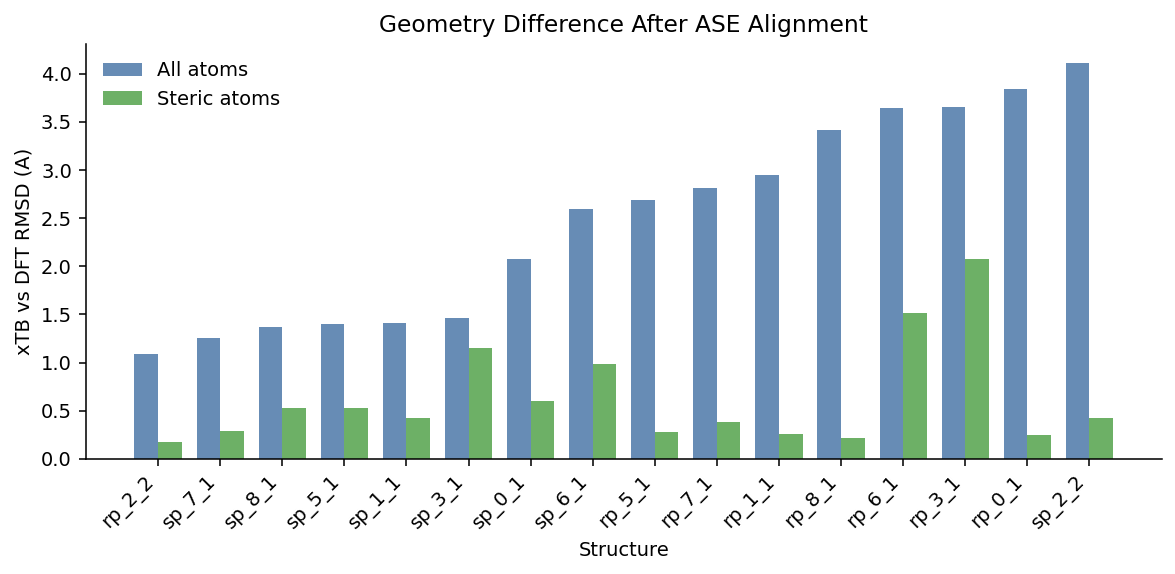

Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/xtb_dft_comparation/results/xtb_dft_rmsd_bar.png


In [8]:
plot_df = summary_df.sort_values('all_atom_rmsd_A')
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = plot_df['series'].map({'rp': '#4c78a8', 'sp': '#4c78a8'}).fillna('#777777')
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width / 2, plot_df['all_atom_rmsd_A'], width=width, color=colors, alpha=0.85, label='All atoms')
ax.bar(x + width / 2, plot_df['steric_atom_rmsd_A'], width=width, color='#54a24b', alpha=0.85, label='Steric atoms')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['structure_id'], rotation=45, ha='right')
ax.set_ylabel('xTB vs DFT RMSD (A)')
ax.set_xlabel('Structure')
ax.set_title('Geometry Difference After ASE Alignment')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
rmsd_fig = RESULT_DIR / 'xtb_dft_rmsd_bar.png'
fig.savefig(rmsd_fig, bbox_inches='tight')
plt.show()
print('Saved:', rmsd_fig)


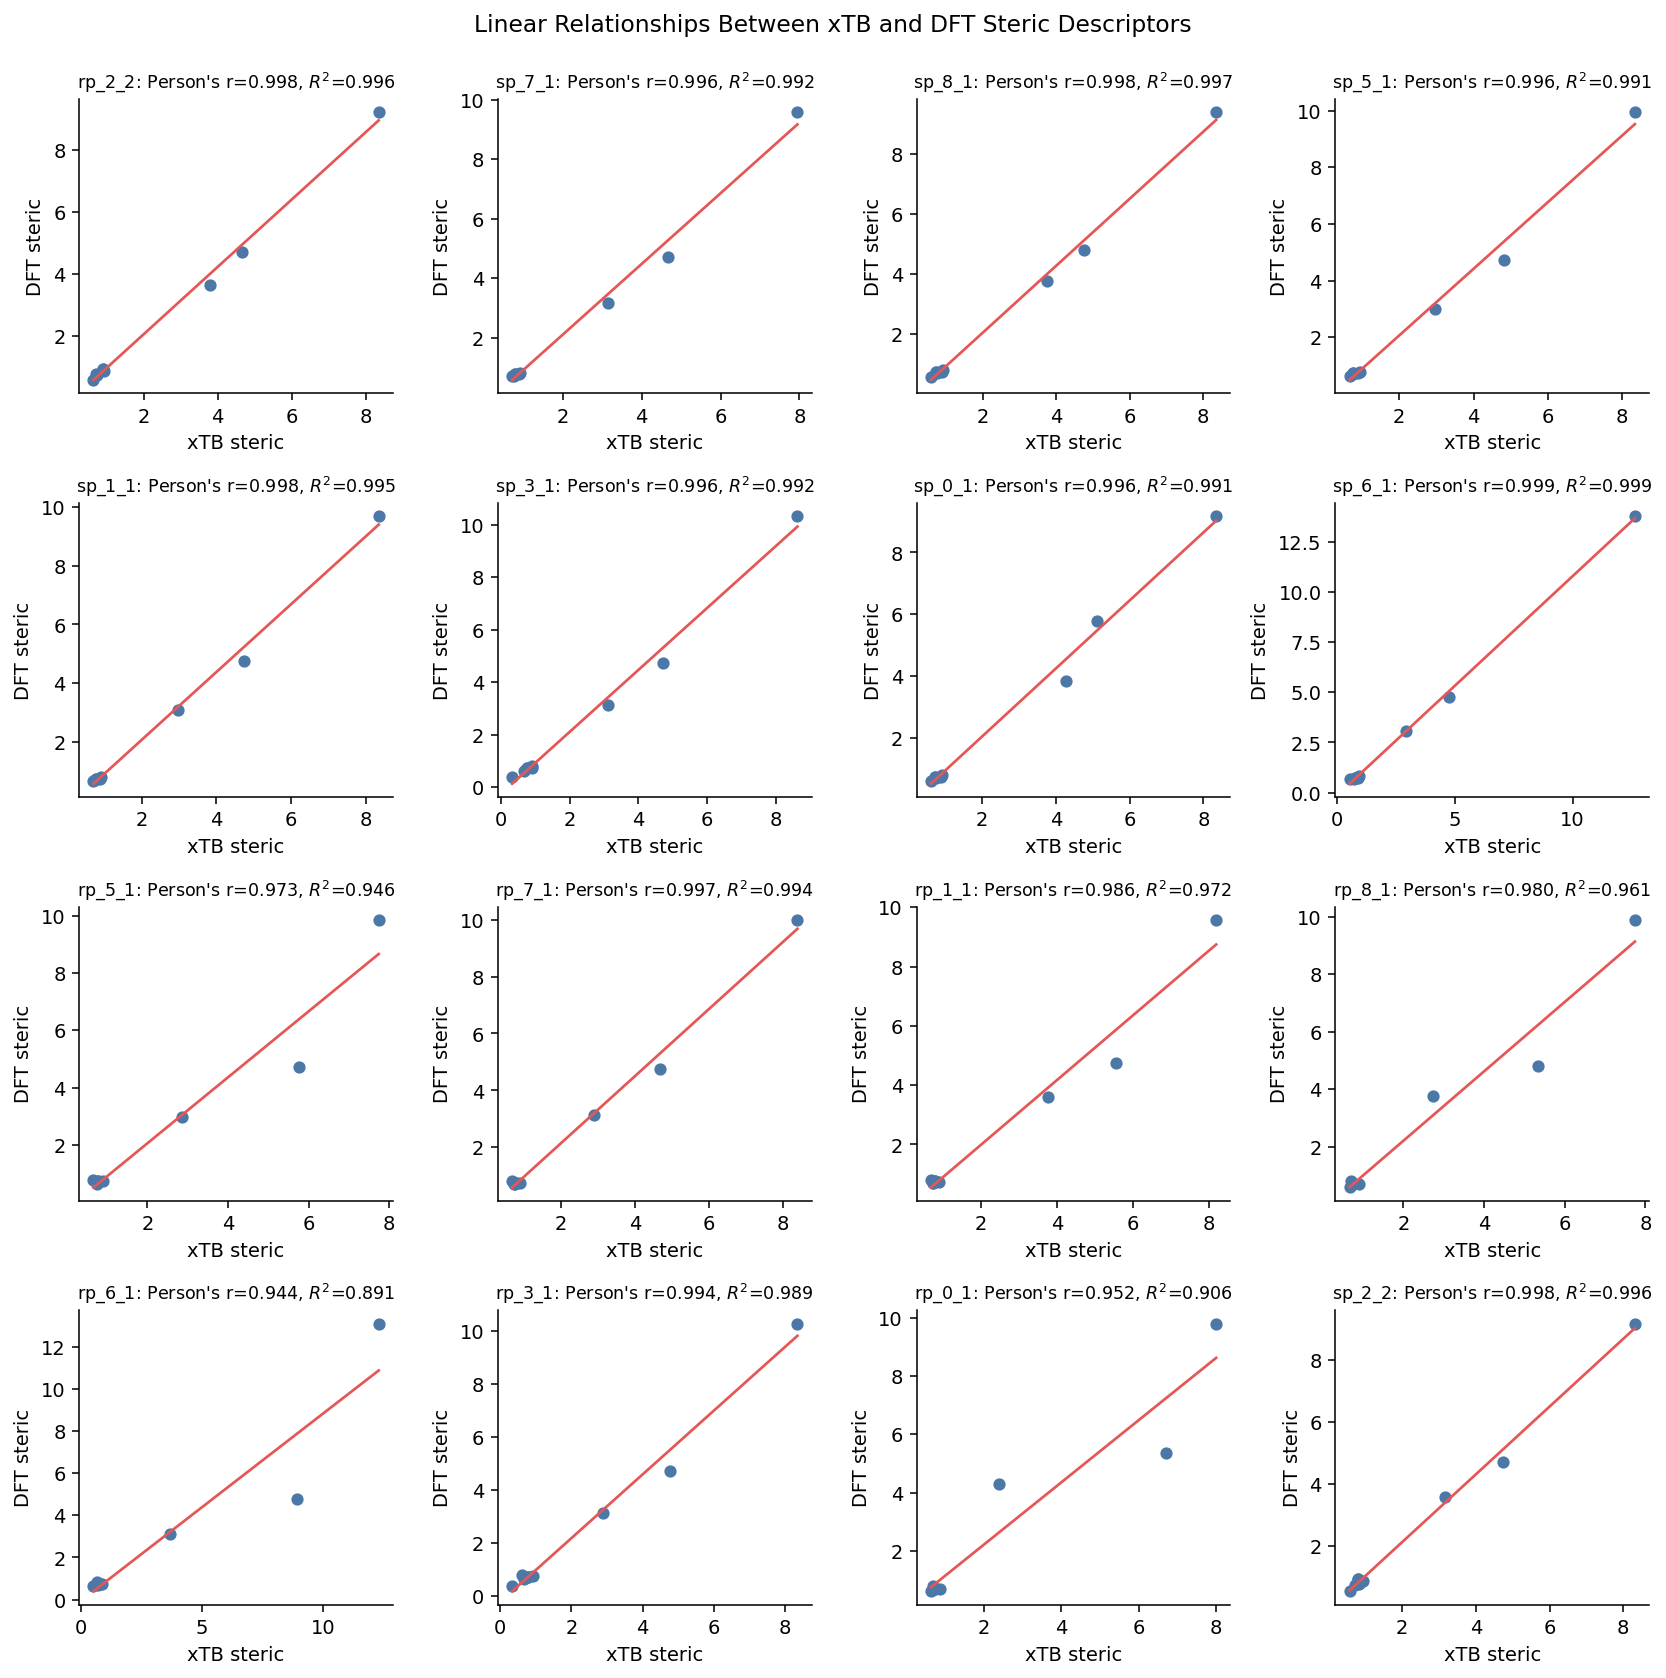

Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/xtb_dft_comparation/results/xtb_dft_steric_linear_relationship.png


In [9]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharex=False, sharey=False)
for ax, structure_id in zip(axes.ravel(), summary_df['structure_id']):
    subset = diff_df[diff_df['structure_id'] == structure_id]
    x = subset['xtb_value'].to_numpy()
    y = subset['dft_value'].to_numpy()
    row = summary_df[summary_df['structure_id'] == structure_id].iloc[0]
    ax.scatter(x, y, s=28, color='#4c78a8')
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = row['steric_linear_slope'] * x_line + row['steric_linear_intercept']
    ax.plot(x_line, y_line, color='#e45756', linewidth=1.4)
    ax.set_title(f'{structure_id}: Person\'s r={row["steric_linear_pearson_r"]:.3f}, $R^2$={row["steric_linear_r2"]:.3f}', fontsize=9)
    ax.set_xlabel('xTB steric')
    ax.set_ylabel('DFT steric')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Linear Relationships Between xTB and DFT Steric Descriptors', y=0.995)
fig.tight_layout()
linear_fig = RESULT_DIR / 'xtb_dft_steric_linear_relationship.png'
fig.savefig(linear_fig, bbox_inches='tight')
plt.show()
print('Saved:', linear_fig)


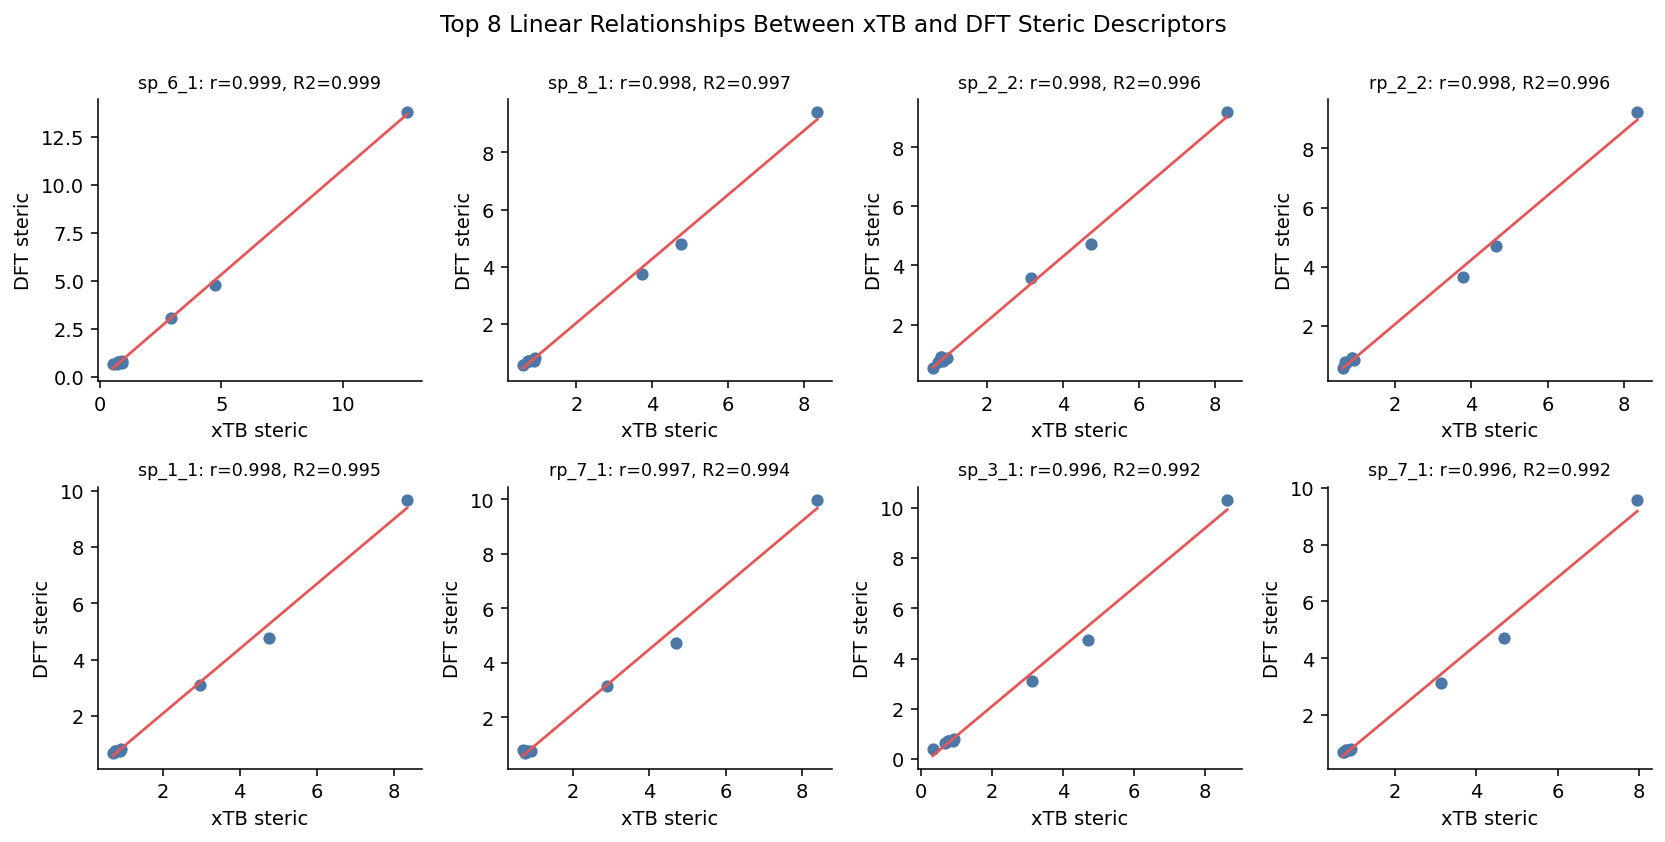

Saved: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/project/SIOC/FerroEnantioML/xtb_dft_comparation/results/xtb_dft_top8_steric_linear_relationship.png


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=False, sharey=False)
for ax, structure_id in zip(axes.ravel(), top8_by_linear['structure_id']):
    subset = diff_df[diff_df['structure_id'] == structure_id]
    x = subset['xtb_value'].to_numpy()
    y = subset['dft_value'].to_numpy()
    row = summary_df[summary_df['structure_id'] == structure_id].iloc[0]
    ax.scatter(x, y, s=28, color='#4c78a8')
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = row['steric_linear_slope'] * x_line + row['steric_linear_intercept']
    ax.plot(x_line, y_line, color='#e45756', linewidth=1.4)
    ax.set_title(f'{structure_id}: r={row["steric_linear_pearson_r"]:.3f}, R2={row["steric_linear_r2"]:.3f}', fontsize=9)
    ax.set_xlabel('xTB steric')
    ax.set_ylabel('DFT steric')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Top 8 Linear Relationships Between xTB and DFT Steric Descriptors', y=0.995)
fig.tight_layout()
linear_fig = RESULT_DIR / 'xtb_dft_top8_steric_linear_relationship.png'
fig.savefig(linear_fig, bbox_inches='tight')
plt.show()
print('Saved:', linear_fig)
